<a href="https://colab.research.google.com/github/ArnavCodes1000101/python_assignment_IIT/blob/SMAS/Assignment03_Q10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload an image:


Saving WhatsApp Image 2026-09-03 at 4.28.21 PM.jpeg to WhatsApp Image 2026-09-03 at 4.28.21 PM (2).jpeg
Image size: 1459 x 1599


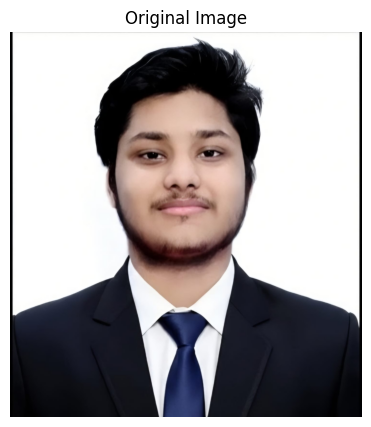


 A1 - Scaling
Matrix:
[[2.  0. ]
 [0.  0.5]]
Rank: 2
T(e1): [2. 0.]
T(e2): [0.  0.5]
Information lost: No


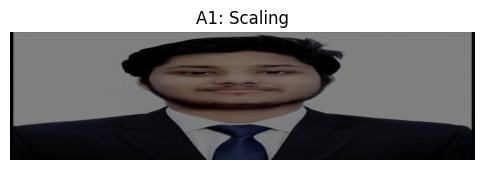


 A2 - 90 Degree Rotation
Matrix:
[[ 0 -1]
 [ 1  0]]
Rank: 2
T(e1): [0 1]
T(e2): [-1  0]
Information lost: No


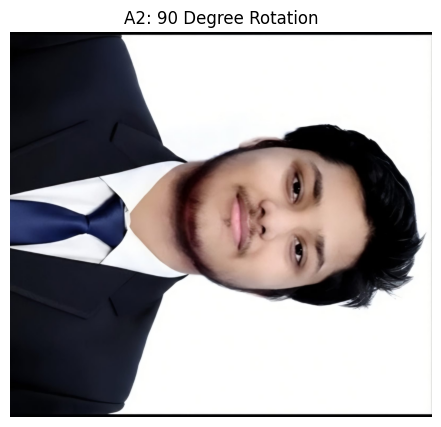


 A3 - Horizontal Shear
Matrix:
[[1 1]
 [0 1]]
Rank: 2
T(e1): [1 0]
T(e2): [1 1]
Information lost: No


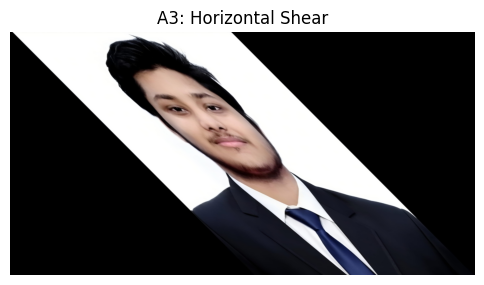


 A4 - Reflection in Y-axis
Matrix:
[[-1  0]
 [ 0  1]]
Rank: 2
T(e1): [-1  0]
T(e2): [0 1]
Information lost: No


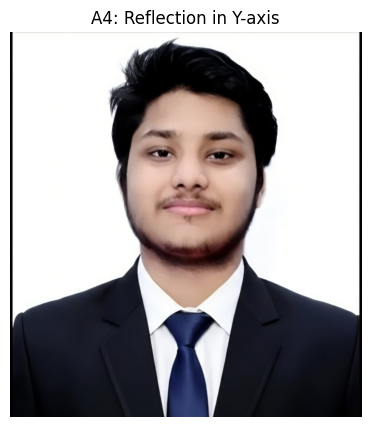


 A5 - Projection onto X-axis
Matrix:
[[1 0]
 [0 0]]
Rank: 1
T(e1): [1 0]
T(e2): [0 0]
Information lost: Yes


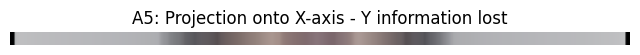


Summary
A1 -> Scaling
A2 -> 90 Degree Rotation
A3 -> Horizontal Shear
A4 -> Reflection in Y-axis
A5 -> Projection onto X-axis


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# Upload image
print("Upload an image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
img = np.array(Image.open(filename).convert("RGB"))
height, width = img.shape[:2]

print("Image size:", width, "x", height)

# Show original image
plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()


# Transformation matrix
A1 = np.array([[2, 0],
               [0, 0.5]])

A2 = np.array([[0, -1],
               [1, 0]])

A3 = np.array([[1, 1],
               [0, 1]])

A4 = np.array([[-1, 0],
               [0, 1]])

A5 = np.array([[1, 0],
               [0, 0]])


def show_matrix(A, name):
    print("\n", name)
    print("Matrix:")
    print(A)
    print("Rank:", np.linalg.matrix_rank(A))
    print("T(e1):", A @ np.array([1, 0]))
    print("T(e2):", A @ np.array([0, 1]))


def transform(A, title):

    cx = (width - 1) / 2
    cy = (height - 1) / 2

    X, Y = np.meshgrid(np.arange(width), np.arange(height))

    Xc = X - cx
    Yc = Y - cy

    new_X = A[0, 0] * Xc + A[0, 1] * Yc
    new_Y = A[1, 0] * Xc + A[1, 1] * Yc

    if np.linalg.matrix_rank(A) == 1:
        projection = np.mean(img, axis=0).astype(np.uint8)
        result = np.tile(projection[np.newaxis, :, :], (30, 1, 1))

        plt.figure(figsize=(8, 2.5))
        plt.imshow(result)
        plt.title(title + " - Y information lost")
        plt.axis("off")
        plt.show()
        return

    new_X += cx
    new_Y += cy

    min_x = int(np.floor(new_X.min()))
    max_x = int(np.ceil(new_X.max()))
    min_y = int(np.floor(new_Y.min()))
    max_y = int(np.ceil(new_Y.max()))

    new_width = max_x - min_x + 1
    new_height = max_y - min_y + 1

    result = np.zeros((new_height, new_width, 3), dtype=np.uint8)

    new_X = np.rint(new_X - min_x).astype(int)
    new_Y = np.rint(new_Y - min_y).astype(int)

    for y in range(height):
        for x in range(width):
            nx = new_X[y, x]
            ny = new_Y[y, x]

            if 0 <= nx < new_width and 0 <= ny < new_height:
                result[ny, nx] = img[y, x]

    plt.figure(figsize=(6, 5))
    plt.imshow(result)
    plt.title(title)
    plt.axis("off")
    plt.show()


# A1 - Scaling
show_matrix(A1, "A1 - Scaling")
print("Information lost: No")
transform(A1, "A1: Scaling")


# A2 - Rotation
show_matrix(A2, "A2 - 90 Degree Rotation")
print("Information lost: No")
transform(A2, "A2: 90 Degree Rotation")


# A3 - Shear
show_matrix(A3, "A3 - Horizontal Shear")
print("Information lost: No")
transform(A3, "A3: Horizontal Shear")


# A4 - Reflection
show_matrix(A4, "A4 - Reflection in Y-axis")
print("Information lost: No")
transform(A4, "A4: Reflection in Y-axis")


# A5 - Projection
show_matrix(A5, "A5 - Projection onto X-axis")
print("Information lost: Yes")
transform(A5, "A5: Projection onto X-axis")


# Summary
print("Summary")
print("A1 -> Scaling")
print("A2 -> 90 Degree Rotation")
print("A3 -> Horizontal Shear")
print("A4 -> Reflection in Y-axis")
print("A5 -> Projection onto X-axis")